# Random Forest — Strategy B: Random Undersampling

A Random Forest classifier is trained using random undersampling, where the majority non-diabetes class is reduced during training to create a balanced dataset. This strategy avoids synthetic data generation but may discard useful majority-class information. Hyperparameter tuning is performed using stratified cross-validation, and model performance is evaluated on the unchanged test set.

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score

In [2]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [3]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

pipeline = Pipeline([
    ("undersampling", RandomUnderSampler(random_state=42)),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2"],
    "model__bootstrap": [True],
}

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train_final, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV ROC AUC:", random_search.best_score_)

Fitting 10 folds for each of 20 candidates, totalling 200 fits
Best parameters: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': 15, 'model__bootstrap': True}
Best CV ROC AUC: 0.8254164307558037


## Final Test Set Evaluation

After hyperparameter tuning, the best model is evaluated on the held-out test set. The test set is not resampled and therefore preserves the original class distribution. Performance is assessed using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

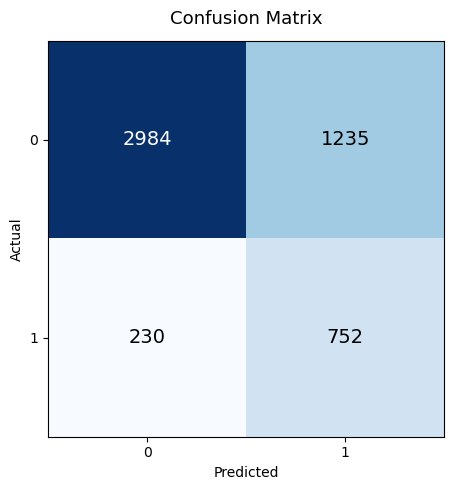

In [4]:
# Plotting confusion matrix
best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test_final)
y_pred_proba = best_model.predict_proba(X_test_final)[:, 1]

conf_matrix = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title("Confusion Matrix", color="black", fontsize=13, pad=12)
ax.set_xlabel("Predicted", color="black")
ax.set_ylabel("Actual", color="black")
ax.tick_params(colors="black")

for text in disp.text_.ravel():
    text.set_color("black")
    text.set_fontsize(14)
disp.text_[0, 0].set_color("white")

plt.tight_layout()
plt.show()

In [5]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7183
ROC AUC: 0.8179
Confusion Matrix:
[[2984 1235]
 [ 230  752]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.71      0.80      4219
         1.0       0.38      0.77      0.51       982

    accuracy                           0.72      5201
   macro avg       0.65      0.74      0.65      5201
weighted avg       0.82      0.72      0.75      5201



## Exporting Model Results

The final evaluation metrics are exported to a CSV file so they can be combined later in a separate model comparison notebook. This avoids retraining models when creating summary tables and visualizations.

In [6]:
metrics = {

    "Strategy": "Undersampling",

    "Model": "Random Forest",

    "Accuracy": accuracy_score(y_test, y_pred),

    "Precision": precision_score(y_test, y_pred),

    "Recall": recall_score(y_test, y_pred),

    "F1-score": f1_score(y_test, y_pred),

    "ROC AUC": roc_auc_score(y_test, y_pred_proba)

}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv("../RESULTS/PERFORMANCE/random_forest_undersampling_metrics.csv", index=False)